In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#拓展实验，搭建 Resnet
class ResBlock(nn.Module):
    def __init__(self, in_channel, out_channel, stride=1):
        super(ResBlock, self).__init__()
        
        self.block = nn.Sequential(
            nn.Conv2d(in_channel, out_channel, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm2d(out_channel),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channel, out_channel, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channel),)
        # [b,in_channel,h,w]=>[b,out_channel,h,w]
        self.extra = nn.Sequential()
        if out_channel != in_channel:
            self.extra = nn.Sequential(
                nn.Conv2d(in_channel, out_channel, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channel),)

    def forward(self, x):

        out = self.block(x)
        out = out + self.extra(x) #resnet 核心，将输入 x 与输出 out 相加
        out = nn.functional.relu(out, inplace=True)
        return out
    
class ResNet18(nn.Module):
    def __init__(self, item=10):
        super(ResNet18, self).__init__()
        self.Conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            ResBlock(64, 64, 1),
            ResBlock(64, 64, 1),
            ResBlock(64, 128, 2),
            ResBlock(128, 128, 1),
            ResBlock(128, 256, 2),
            ResBlock(256, 256, 1),
            ResBlock(256, 512, 2),
            ResBlock(512,512,1),
            # [b,512,h,w]=>[b,512,1,1]
            nn.AdaptiveAvgPool2d([1, 1])
            )
        self.linear = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, item),
            )

    def forward(self, x):
        x = self.Conv(x)
        x = self.linear(x)
        return x

In [3]:
import torch

# define the accuracy evaluation method
def evaluate_accuracy(loader, model):
    num_correct = 0
    num_samples = 0

    model.eval()
    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            x = x.to(device=device, dtype=torch.float32)
            y = y.to(device=device, dtype=torch.long)
            scores = model(x)
            _, preds = scores.max(1)
            num_correct += (preds == y).sum()
            num_samples += preds.size(0)
        accuracy = float(num_correct / num_samples)
        print('Number of correct sample %d / %d correct (%.2f)' % (num_correct, num_samples, 100 * accuracy))
        return accuracy

In [4]:
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import DataLoader
from torch.utils.data import sampler
import torchvision.datasets as dset
import torchvision.transforms as T
import torch.nn.functional as F
import torchvision.models as models
import numpy as np
import copy

NUM_TRAIN = 49000

# 数据预处理，减去cifar-10数据均值
transform_normal = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),(0.2023, 0.1994, 0.2010))
])


# 加载训练集
cifar10_train = dset.CIFAR10('数据集/data/CIFAR10', train=True, download=True, transform=transform_normal)
loader_train = DataLoader(cifar10_train, batch_size=128, sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN)))

# 加载验证集
cifar10_val = dset.CIFAR10('数据集/data/CIFAR10', train=True, download=True, transform=transform_normal)
loader_val = DataLoader(cifar10_val, batch_size=128, sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN, 50000)))

# 加载测试集
cifar10_test = dset.CIFAR10('数据集/data/CIFAR10', train=False, download=True, transform=transform_normal)
loader_test = DataLoader(cifar10_test, batch_size=64)

learning_rate = 1e-3
epochs = 50
model = ResNet18().to(device)
# optimizer_resnet = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, nesterov=True)
optimizer_resnet = optim.Adam(model.parameters(), lr=learning_rate)

losses = []
accuracies = []

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Epoch 0, iter 0, loss=2.7375
Epoch 0, iter 100, loss=1.9280
Epoch 0, iter 200, loss=1.7694
Epoch 0, iter 300, loss=1.5040
Epoch 0, iter 400, loss=1.5796
Epoch 0, iter 500, loss=1.5637
Epoch 0, iter 600, loss=1.4084
Epoch 0, iter 700, loss=1.5156
Number of correct sample 440 / 1000 correct (44.00)
Epoch 1, iter 0, loss=1.3636
Epoch 1, iter 100, loss=1.2914
Epoch 1, iter 200, loss=1.2420
Epoch 1, iter 300, loss=1.2648
Epoch 1, iter 400, loss=1.3213
Epoch 1, iter 500, loss=1.2202
Epoch 1, iter 600, loss=1.1940
Epoch 1, iter 700, loss=1.1211
Number of correct sample 526 / 1000 correct (52.60)
Epoch 2, iter 0, loss=1.1975
Epoch 2, iter 100, loss=1.1706
Epoch 2, iter 200, loss=1.1060
Epoch 2, iter 300, loss=1.5428
Epoch 2, iter 400, loss=1.1036
Epoch 2, iter 500, loss=0.9468
Epoch 2, iter 600, loss=0.9751
Epoch 2, iter 700, loss=1.1124
Number of correct sample 655 / 1000 correct 

In [ ]:
def train():
    for e in range(epochs):
        loss_iter = []
        for t, (x, y) in enumerate(loader_train):
            x = x.to(device)
            y = y.to(device)
            model.train()
            scores = model(x)
            loss = F.cross_entropy(scores, y).to(device)
            loss_iter.append(loss.item())

            optimizer_resnet.zero_grad()
            loss.backward()
            optimizer_resnet.step()

            if t%100==0:
                print('Epoch %d, iter %d, loss=%.4f' % (e+1, t,  loss.item()))

        losses.append(np.mean(loss_iter))
        accuracy = evaluate_accuracy(loader_val, model)
        accuracies.append(accuracy)

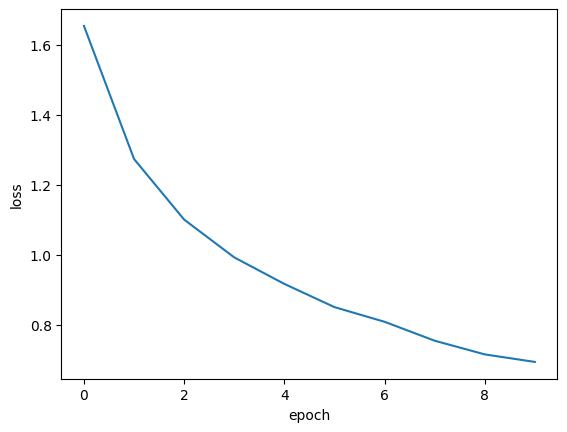

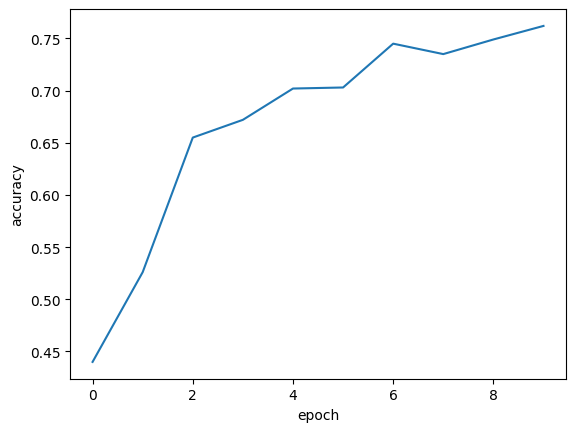

In [5]:
# 画出 loss 曲线和 accuracy 曲线
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

plt.plot(accuracies)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()


In [7]:
from torch.utils.data import Subset
import tqdm

#加载数据，并划分数据集和测试集大小
train_data = Subset(train_data, range(0,10000)) #划分训练集，大小为 10K
test_data = Subset(test_data, range(0,10000)) #划分测试集，大小为 10K
#测试最佳模型每一个类别的正确率
model = model.to(device)
model.eval()
correct = torch.zeros(10, device=device) #每个类别预测正确个数初始化
num = torch.zeros(10, device=device) #每个类别数目初始化
batch_size = 1
test_data_loader = DataLoader(test_data, batch_size=batch_size)
print("----测试开始----")
with torch.no_grad():
    for data in tqdm(test_data_loader):
        imgs, targets = data
        imgs = imgs.to(device)
        targets = targets.to(device)
        output = model(imgs)
        if output.argmax(1) == targets :
            correct[targets] += 1 #若预测正确，对应类别+1
            num[targets] += 1 #计算每一类的数目
accuracy = correct/num
print("每一个类别的正确率为：")
print(accuracy)
accuracy=accuracy.tolist()
label = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
df = pd.DataFrame(dict(label=label,accuracy=accuracy))
df.to_excel("test_result1.xlsx",index=False) #将预测结果存入 excel

----测试开始----


TypeError: 'module' object is not callable